# 🔴⚫ THOMASSON ENGINE v11 — RC Lens Data Scouting
**Auteur : Zakaria**

---

## Problématique
Identifier le successeur d'**Adrien Thomasson (32 ans)** dans les Big 5.  
Profil cible : **Pressing Playmaker hybride** — MF capable de presser haut ET de créer.

---

## Nouveautés v11 (recommandations Data Scientist Senior)

| # | Recommandation | Statut | Justification |
|---|---|---|---|
| 1 | **Coefficient UEFA par ligue** | ✅ Intégré | `league_name` disponible dans big5_stats — appliqué sur TklW et Int (métriques contextuelles) |
| 2 | **k-NN Cosine Similarity** | ✅ Intégré | Remplace le score arbitraire — sélection mathématique des plus proches voisins de Thomasson sur 9D |
| 3 | **Progressive Carries** | ⏭️ Ignoré | `PrgC` absent des exports FBRef disponibles — limiter aux données en main |
| 4 | **Scatter KP vs TklW** | ✅ Intégré | Ajouté comme fig3 — très lisible pour situer la shortlist dans le nuage |

---

## Contraintes de recrutement
| Critère | Valeur |
|---|---|
| **Budget** | ≤ 15 M€ (Transfermarkt mars 2026) |
| **Âge** | ≤ 29 ans |
| **Minutes** | ≥ 50% du temps de jeu de Thomasson (~961 min) |
| **Poste** | MF confirmé (FBRef + SofaScore) |
| **Club exclu** | RC Lens |

## 0. Imports & Palette RC Lens

In [16]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')

os.makedirs('src/figures', exist_ok=True)
FIGDIR = 'src/figures'

R  = '#E30613'; OR = '#F5A623'; F  = '#0D0D0D'; F2 = '#141414'
W  = '#F0F0F0'; G  = '#777777'; G2 = '#2A2A2A'
VT = '#4CAF50'; OG = '#FF9800'; PU = '#9C27B0'; B  = '#00A8E8'; AQ = '#00BCD4'

plt.rcParams.update({
    'figure.facecolor':F, 'axes.facecolor':F2, 'text.color':W,
    'axes.labelcolor':W,  'xtick.color':G,      'ytick.color':G,
    'axes.edgecolor':G2,  'axes.grid':True,     'grid.color':G2,
    'grid.linewidth':0.5, 'font.family':'DejaVu Sans',
})
print("✅ Environnement prêt — Thomasson Engine v11")

✅ Environnement prêt — Thomasson Engine v11


## 1. Chargement des sources

In [17]:
big5  = pd.read_csv('big5_stats.csv',         sep=';', on_bad_lines='skip')
misc  = pd.read_csv('Miscellaneous_Stats.csv', on_bad_lines='skip')
defdf = pd.read_csv('stats_joueurs_final.csv', on_bad_lines='skip')
shoot = pd.read_csv('Shooting_Stats.csv',      on_bad_lines='skip')

for df in [misc, shoot]:
    df['_player'] = df['1_level_0_Player'].astype(str).str.strip()
defdf['_player']   = defdf['Player'].astype(str).str.strip()
defdf['Pos_fbref'] = defdf['Pos'].astype(str).str.strip()

print(f"big5  {big5.shape}  — SofaScore (league_name disponible)")
print(f"misc  {misc.shape}  — FBRef Misc")
print(f"defdf {defdf.shape}  — FBRef Defensive")
print(f"shoot {shoot.shape}  — FBRef Shooting")

big5  (5248, 97)  — SofaScore (league_name disponible)
misc  (2653, 23)  — FBRef Misc
defdf (2653, 27)  — FBRef Defensive
shoot (2670, 21)  — FBRef Shooting


## 2. Nettoyage, Fusion & Coefficient UEFA

### Rec 1 — Ajustement par niveau de ligue ✅
Les métriques défensives **TklW** et **Int** sont pondérées par un coefficient UEFA basé sur la difficulté de chaque ligue.  
Un tacle gagné en Premier League vaut plus qu'en Ligue 1 (base de référence = Thomasson).

| Ligue | Coef. UEFA |
|---|---|
| Premier League | × 1.22 |
| La Liga | × 1.20 |
| Bundesliga | × 1.08 |
| Serie A | × 1.05 |
| Ligue 1 | × 1.00 *(base)* |

> **Périmètre d'application** : uniquement TklW/90 et Int/90 (métriques contextuelles — dépendent du niveau d'opposition).  
> La création (KP, xA) et la transition (Drib, Pass%) ne sont pas ajustées car elles dépendent davantage du système de jeu.

In [18]:
# ── Nettoyage SofaScore ───────────────────────────────────────────────────────
COLS_NUM = [
    'minutesPlayed','rating','goals','assists','expectedGoals','expectedAssists',
    'keyPasses','tackles','interceptions','accuratePassesPercentage',
    'successfulDribbles','bigChancesCreated','fouls','wasFouled',
    'groundDuelsWonPercentage','aerialDuelsWonPercentage','player_age',
    'accurateFinalThirdPasses','clearances','accurateCrosses','appearances',
]
for c in COLS_NUM:
    big5[c] = pd.to_numeric(big5[c], errors='coerce')
big5 = big5.dropna(subset=['player__name','minutesPlayed','rating'])
big5 = big5[~big5['player__name'].str.contains('Translation|nameTranslation', na=False)]
big5 = (big5.sort_values('minutesPlayed', ascending=False)
             .drop_duplicates('player__name', keep='first')
             .reset_index(drop=True))
big5['_player'] = big5['player__name'].str.strip()

# ── Rec 1 : Coefficient UEFA par ligue ───────────────────────────────────────
UEFA_COEF = {
    'Premier League' : 1.22,
    'La liga'        : 1.20,   # casse exacte SofaScore
    'Bundesliga'     : 1.08,
    'Serie A'        : 1.05,
    'Ligue 1'        : 1.00,   # base — Thomasson joue en L1
}
big5['league_coef'] = big5['league_name'].map(UEFA_COEF).fillna(1.00)

LENS_MASK    = big5['team__name'].str.contains('Lens', na=False, case=False)
joueurs_lens = big5[LENS_MASK]['player__name'].tolist()

# ── FBRef sources ─────────────────────────────────────────────────────────────
for c in ['Performance_TklW','Performance_Int','Performance_Crs']:
    misc[c] = pd.to_numeric(misc[c], errors='coerce')
misc_s = misc[['_player','Performance_TklW','Performance_Int','Performance_Crs']].rename(
    columns={'Performance_TklW':'TklW_misc','Performance_Int':'Int_misc','Performance_Crs':'Crs_misc'})

defdf['TklW'] = pd.to_numeric(defdf['TklW'], errors='coerce')
defdf['Int']  = pd.to_numeric(defdf['Int'],  errors='coerce')
def_s = defdf[['_player','TklW','Int','Pos_fbref']].rename(
    columns={'TklW':'TklW_def','Int':'Int_def'})

for c in ['Standard_Sh/90','Standard_SoT/90']:
    shoot[c] = pd.to_numeric(shoot[c], errors='coerce')
shoot_s = shoot[['_player','Standard_Sh/90','Standard_SoT/90']].rename(
    columns={'Standard_Sh/90':'Sh90','Standard_SoT/90':'SoT90'})

# ── Fusion + imputation ───────────────────────────────────────────────────────
df = big5[big5['minutesPlayed'] >= 600].copy()
df = (df.merge(misc_s, on='_player', how='left')
        .merge(def_s,  on='_player', how='left')
        .merge(shoot_s,on='_player', how='left'))

df['_pos_sofa'] = df['player_position'].astype(str).str.strip()
for col in ['TklW_misc','Int_misc','Crs_misc','TklW_def','Int_def','SoT90','Sh90']:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df.groupby('_pos_sofa')[col].transform('median')).fillna(df[col].median())

# ── Filtres positions ─────────────────────────────────────────────────────────
EXCL_POS      = ['DF,MF','DF','GK','FW','DF,FW']
FAUX_POSITIFS = ['Federico Dimarco','Lamine Yamal','Abdessamad Ezzalzouli','Ferran Torres','Dani Olmo']

is_mf_sofa  = df['player_position'].str.contains('MF', na=False)
is_not_excl = ~df['Pos_fbref'].isin(EXCL_POS)
is_not_faux = ~df['player__name'].isin(FAUX_POSITIFS)
idx_lens    = LENS_MASK.reindex(df.index, fill_value=False)

T_raw = df[df['player__name'].str.contains('Thomasson', na=False)].copy()
pool  = (df[is_mf_sofa & is_not_excl & is_not_faux & ~idx_lens]
         .drop_duplicates('player__name', keep='first')
         .reset_index(drop=True))

print(f"Pool : {len(pool)} MF uniques  |  RC Lens exclus : {len(joueurs_lens)}  |  Thomasson : {len(T_raw)} ligne")
print()
print("Coefficient ligue appliqué :")
print(big5[['league_name','league_coef']].drop_duplicates().sort_values('league_coef', ascending=False).to_string(index=False))

Pool : 643 MF uniques  |  RC Lens exclus : 24  |  Thomasson : 1 ligne

Coefficient ligue appliqué :
   league_name  league_coef
Premier League         1.22
       La liga         1.20
    Bundesliga         1.08
       Serie A         1.05
       Ligue 1         1.00


## 3. Feature Engineering & Scores v11

### Modification vs v10
- **TklW_p90** et **Int_def_p90** multipliés par `league_coef` avant calcul du score Pressing  
- Score final conservé (40/40/20) mais enrichi par la pondération ligue

In [19]:
def add_p90(d):
    d = d.copy()
    d['p90'] = d['minutesPlayed'] / 90.0
    for c in ['goals','assists','expectedGoals','expectedAssists','keyPasses',
              'tackles','interceptions','bigChancesCreated','successfulDribbles',
              'fouls','wasFouled','clearances','accurateCrosses','accurateFinalThirdPasses']:
        if c in d.columns:
            d[f'{c}_p90'] = d[c] / d['p90']
    if 'TklW_def' in d.columns: d['TklW_p90']    = d['TklW_def'] / d['p90']
    if 'Int_def'  in d.columns: d['Int_def_p90'] = d['Int_def']  / d['p90']
    if 'SoT90'    in d.columns: d['SoT_p90']     = d['SoT90']
    return d

def compute_scores_v11(d):
    d = d.copy()
    def gc(col):
        return d[col].fillna(0) if col in d.columns else pd.Series(0, index=d.index)
    coef = d['league_coef'].fillna(1.0) if 'league_coef' in d.columns else pd.Series(1.0, index=d.index)

    # PRESSING (40%) — TklW et Int ajustés par coefficient UEFA
    d['s_press'] = (
        gc('TklW_p90') * coef                * 0.40 +
        gc('interceptions_p90') * coef       * 0.30 +
        gc('groundDuelsWonPercentage') / 100 * 0.20 +
        gc('clearances_p90')                 * 0.10
    )
    # CRÉATION (40%) — inchangé (non contextualisé)
    d['s_crea'] = (
        gc('keyPasses_p90')         * 0.30 +
        gc('expectedAssists_p90')   * 0.25 +
        gc('bigChancesCreated_p90') * 0.25 +
        gc('assists_p90')           * 0.20
    )
    # TRANSITION (20%) — inchangé
    d['s_trans'] = (
        gc('successfulDribbles_p90')          * 0.35 +
        gc('accurateFinalThirdPasses_p90')    * 0.35 +
        gc('accuratePassesPercentage') / 100  * 0.30
    )
    d['s_final'] = d['s_press']*0.40 + d['s_crea']*0.40 + d['s_trans']*0.20
    return d

pool  = compute_scores_v11(add_p90(pool))
T_df  = compute_scores_v11(add_p90(T_raw))

all_mf = (pd.concat([pool, T_df], ignore_index=True)
            .drop_duplicates('player__name', keep='first'))
for s in ['s_final','s_press','s_crea','s_trans']:
    all_mf[f'{s}_n'] = MinMaxScaler((0,100)).fit_transform(all_mf[[s]])

T  = all_mf[all_mf['player__name'].str.contains('Thomasson', na=False)].iloc[0]
MF = all_mf[~all_mf['player__name'].str.contains('Thomasson', na=False)].copy()
MF['player_age'] = pd.to_numeric(MF['player_age'], errors='coerce')

print(f"THOMASSON v11 — Scores normalisés :")
print(f"  Final (avec coef ligue) : {T['s_final_n']:.1f}/100")
print(f"  Pressing  (coef L1=1.0) : {T['s_press_n']:.1f}/100")
print(f"  Création                : {T['s_crea_n']:.1f}/100")
print(f"  Transition              : {T['s_trans_n']:.1f}/100")

THOMASSON v11 — Scores normalisés :
  Final (avec coef ligue) : 36.7/100
  Pressing  (coef L1=1.0) : 37.5/100
  Création                : 65.0/100
  Transition              : 23.6/100


## 4. Rec 2 — k-NN Cosine Similarity ✅

Au lieu d'un score arbitraire, on utilise **9 métriques /90 normalisées** pour trouver mathématiquement les milieux dont le radar est le plus proche de celui de Thomasson.

**Avantages vs score pondéré :**  
- Pas de biais lié aux poids choisis manuellement  
- Mesure de similitude globale sur toutes les dimensions simultanément  
- Résistant aux outliers sur une dimension isolée

In [20]:
# ── Rec 2 : k-NN Cosine Similarity ───────────────────────────────────────────
KNN_FEATURES = [
    'TklW_p90', 'interceptions_p90', 'groundDuelsWonPercentage',
    'keyPasses_p90', 'expectedAssists_p90', 'bigChancesCreated_p90',
    'successfulDribbles_p90', 'accurateFinalThirdPasses_p90', 'accuratePassesPercentage',
]

feat_matrix = all_mf[KNN_FEATURES].fillna(0)
feat_scaled = MinMaxScaler().fit_transform(feat_matrix)

knn = NearestNeighbors(n_neighbors=31, metric='cosine')
knn.fit(feat_scaled)

T_idx = all_mf[all_mf['player__name'].str.contains('Thomasson', na=False)].index[0]
T_vec = feat_scaled[T_idx].reshape(1, -1)
dists, idxs = knn.kneighbors(T_vec)

# Stocker la similarité pour chaque joueur
all_mf['knn_sim'] = 0.0
for d, i in zip(dists[0][1:], idxs[0][1:]):
    all_mf.loc[i, 'knn_sim'] = (1 - d) * 100

MF = all_mf[~all_mf['player__name'].str.contains('Thomasson', na=False)].copy()
MF['player_age'] = pd.to_numeric(MF['player_age'], errors='coerce')

print("TOP 10 PLUS PROCHES VOISINS DE THOMASSON (cosine similarity) :")
print(f"{'#':>2}  {'Joueur':<28} {'Club':<24} {'Âge':>4} {'Min':>6} {'Sim%':>7}")
print("-"*75)
for i,(d,idx) in enumerate(zip(dists[0][1:11], idxs[0][1:11]),1):
    r   = all_mf.iloc[idx]
    sim = (1-d)*100
    print(f"{i:>2}  {r['player__name']:<28} {str(r['team__name']):<24} "
          f"{r['player_age']:>4.0f} {r['minutesPlayed']:>6.0f} {sim:>7.1f}%")

TOP 10 PLUS PROCHES VOISINS DE THOMASSON (cosine similarity) :
 #  Joueur                       Club                      Âge    Min    Sim%
---------------------------------------------------------------------------
 1  Anton Stach                  Leeds United               27   1782    98.8%
 2  Paul Nebel                   1. FSV Mainz 05            23   1150    98.3%
 3  Pere Milla                   Espanyol                   33   1536    98.0%
 4  Kevin Stöger                 Borussia M'gladbach        32    692    97.9%
 5  Andrea Cambiaso              Juventus                   25   1861    97.8%
 6  Lovro Majer                  VfL Wolfsburg              28   1194    97.6%
 7  Carles Aleñá                 Deportivo Alavés           28   1554    97.3%
 8  Christian Eriksen            VfL Wolfsburg              34   1485    97.2%
 9  William Mikelbrencis         Hamburger SV               21    644    97.2%
10  Rubén García                 Osasuna                    32   1423   

## 5. Filtres de recrutement

In [21]:
# ── Valeurs de marché (Transfermarkt mars 2026) ───────────────────────────────
VALEURS = {
    'Aron Dønnum':5.0, 'Edu Expósito':10.0, 'Patrizio Masini':3.0,
    'Romain Del Castillo':5.0, 'Vitaly Janelt':10.0, 'Afonso Moreira':4.0,
    'Aarón Martín':8.0, 'Kassoum Ouattara':6.0, 'Mehdi Léris':3.0,
    'Elliot Anderson':15.0, 'Florentino Luís':12.0, 'Hugo Bueno':8.0,
    'Tim Iroegbunam':12.0, 'Johann Lepenant':5.0, 'Nathaniel Brown':5.0,
    'Ander Barrenetxea':10.0, 'Cristian Cásseres Jr.':8.0, 'Martin Frese':4.0,
    'Jan-Niklas Beste':10.0, 'Saša Lukić':8.0, 'Youri Tielemans':10.0,
    'Kévin Danois':10.0, 'Anton Stach':25.0, 'Paul Nebel':5.0,
    'Andrea Cambiaso':40.0, 'Lovro Majer':10.0, 'Carles Aleñá':3.0,
    'Pere Milla':3.0, 'James Garner':35.0, 'Mikkel Damsgaard':20.0,
    'Nicolò Fagioli':20.0, 'João Gomes':35.0, 'Rayan Cherki':50.0,
    'Jude Bellingham':200.0, 'Pedri':80.0, 'Declan Rice':120.0,
    'Moisés Caicedo':100.0, 'Mateus Fernandes':20.0, 'Nicolò Barella':60.0,
    'Bukayo Saka':150.0, 'Lamine Camara':40.0, 'Patrick Dorgu':40.0,
    'Arda Güler':35.0,
}

MF['valeur_m'] = MF['player__name'].map(VALEURS)

MIN_THRESH = T['minutesPlayed'] * 0.50
BUDGET_MAX = 15.0
AGE_MAX    = 29

n0 = len(MF)
MF_min = MF[MF['minutesPlayed'] >= MIN_THRESH].copy(); n1 = len(MF_min)
MF_age = MF_min[MF_min['player_age'] <= AGE_MAX].copy(); n2 = len(MF_age)
MF_bud = MF_age[MF_age['valeur_m'].notna() & (MF_age['valeur_m'] <= BUDGET_MAX)].copy(); n3 = len(MF_bud)
ETAPES = [n0, n1, n2, n3]

print(f"{'Pool MF total':<32}: {n0:>4}")
print(f"{'≥ '+str(int(MIN_THRESH))+' min':<32}: {n1:>4}  (-{n0-n1})")
print(f"{'≤ '+str(AGE_MAX)+' ans':<32}: {n2:>4}  (-{n1-n2})")
print(f"{'≤ '+str(BUDGET_MAX)+'M€ (valeur connue)':<32}: {n3:>4}  (-{n2-n3})")
print()
print("TOP 10 après filtres (classés par k-NN Similarité) :")
print(f"{'#':>2}  {'Joueur':<26} {'Club':<22} {'Âge':>4} {'Sim%':>7} {'Score':>6} {'Val':>7}")
print("-"*75)
for i,(_,r) in enumerate(MF_bud.nlargest(10,'knn_sim').iterrows(),1):
    print(f"{i:>2}  {r['player__name']:<26} {str(r['team__name']):<22} "
          f"{r['player_age']:>4.0f} {r['knn_sim']:>7.1f}% "
          f"{r['s_final_n']:>6.1f} ~{r['valeur_m']:>4.0f}M€")

Pool MF total                   :  642
≥ 961 min                       :  471  (-171)
≤ 29 ans                        :  385  (-86)
≤ 15.0M€ (valeur connue)        :   24  (-361)

TOP 10 après filtres (classés par k-NN Similarité) :
 #  Joueur                     Club                    Âge    Sim%  Score     Val
---------------------------------------------------------------------------
 1  Paul Nebel                 1. FSV Mainz 05          23    98.3%   33.7 ~   5M€
 2  Lovro Majer                VfL Wolfsburg            28    97.6%   30.0 ~  10M€
 3  Carles Aleñá               Deportivo Alavés         28    97.3%   38.2 ~   3M€
 4  Aron Dønnum                Toulouse                 27    96.9%   37.1 ~   5M€
 5  Romain Del Castillo        Stade Brestois           29    96.7%   36.6 ~   5M€
 6  Aarón Martín               Genoa                    28    95.9%   29.1 ~   8M€
 7  Elliot Anderson            Nottingham Forest        23     0.0%   55.5 ~  15M€
 8  Kévin Danois            

## 6. Shortlist finale v11 — k-NN + Filtres

In [22]:
# Shortlist v11 — Top 5 k-NN éligibles
SHORTLIST_V11 = {
    'Paul Nebel'          : ('FSV Mainz 05',     'Bundesliga', 5.0,  '23 ans', B),
    'Lovro Majer'         : ('VfL Wolfsburg',    'Bundesliga', 10.0, '28 ans', VT),
    'Carles Aleñá'        : ('Dep. Alavés',      'La Liga',    3.0,  '28 ans', OR),
    'Aron Dønnum'         : ('Toulouse',         'Ligue 1',    5.0,  '27 ans', PU),
    'Romain Del Castillo' : ('Stade Brestois',   'Ligue 1',    5.0,  '29 ans', OG),
}

print("SHORTLIST v11")
print("=" * 100)
hdr = (f"{'Joueur':<22} {'Club':<18} {'Âge':>5} {'Budget':>8}  "
       f"{'Sim%':>7} {'Score':>6} {'Press':>6} {'Crea':>6} {'Trans':>6}  "
       f"{'TklW':>6} {'KP':>5} {'xA':>6} {'Min':>6}")
print(hdr); print("-"*100)

print(f"{'Thomasson (REF)':<22} {'RC Lens':<18} {T['player_age']:>5.0f} {'—':>8}  "
      f"{'—':>7} {T['s_final_n']:>6.1f} {T['s_press_n']:>6.1f} {T['s_crea_n']:>6.1f} {T['s_trans_n']:>6.1f}  "
      f"{T.get('TklW_p90',0):>6.2f} {T.get('keyPasses_p90',0):>5.2f} "
      f"{T.get('expectedAssists_p90',0):>6.3f} {T['minutesPlayed']:>6.0f}")
print("-"*100)

for name,(club,ligue,bud,age,col) in SHORTLIST_V11.items():
    kw = name.split()[-1]
    r  = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        print(f"{r['player__name']:<22} {club:<18} {r['player_age']:>5.0f} ~{bud:>5.0f}M€  "
              f"{r['knn_sim']:>7.1f}% {r['s_final_n']:>6.1f} {r['s_press_n']:>6.1f} "
              f"{r['s_crea_n']:>6.1f} {r['s_trans_n']:>6.1f}  "
              f"{r.get('TklW_p90',0):>6.2f} {r.get('keyPasses_p90',0):>5.2f} "
              f"{r.get('expectedAssists_p90',0):>6.3f} {r['minutesPlayed']:>6.0f}")

SHORTLIST v11
Joueur                 Club                 Âge   Budget     Sim%  Score  Press   Crea  Trans    TklW    KP     xA    Min
----------------------------------------------------------------------------------------------------
Thomasson (REF)        RC Lens               32        —        —   36.7   37.5   65.0   23.6    1.55  2.43  0.190   1922
----------------------------------------------------------------------------------------------------
Paul Nebel             FSV Mainz 05          23 ~    5M€     98.3%   33.7   30.4   44.2   27.5    1.10  1.80  0.153   1150
Lovro Majer            VfL Wolfsburg         28 ~   10M€     97.6%   30.0   32.3   40.9   22.7    1.13  1.51  0.156   1194
Carles Aleñá           Dep. Alavés           28 ~    3M€     97.3%   38.2   36.4   44.3   31.0    1.27  1.56  0.147   1554
Aron Dønnum            Toulouse              27 ~    5M€     96.9%   37.1   35.3   61.4   25.8    1.23  2.30  0.261   1681
Romain Del Castillo    Stade Brestois        29 

## 7. Visualisations

### Fig 1 — Radar Thomasson (9D)

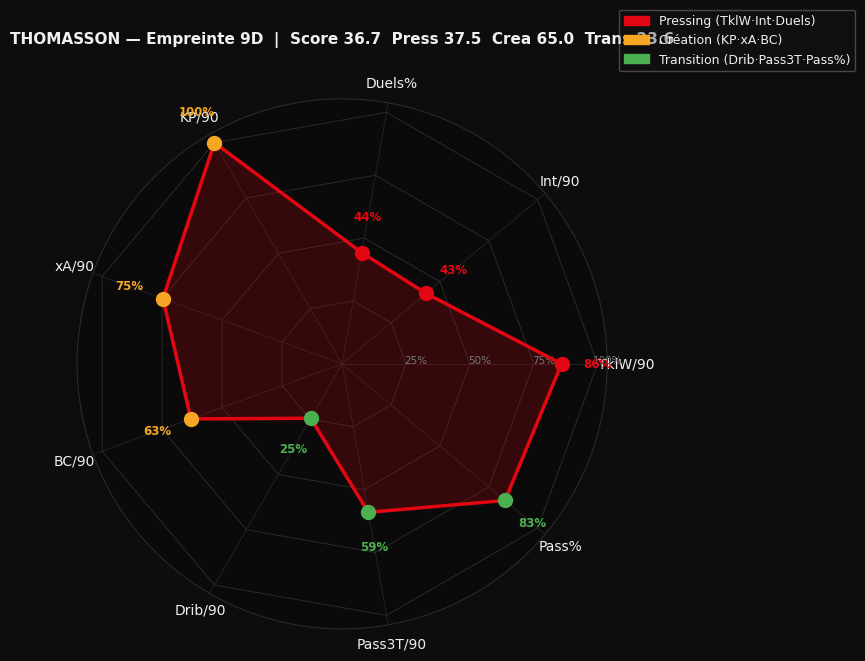

✅ fig1


In [23]:
RADAR_LABELS = ['TklW/90','Int/90','Duels%','KP/90','xA/90','BC/90','Drib/90','Pass3T/90','Pass%']
RADAR_COLS   = ['TklW_p90','interceptions_p90','groundDuelsWonPercentage',
                'keyPasses_p90','expectedAssists_p90','bigChancesCreated_p90',
                'successfulDribbles_p90','accurateFinalThirdPasses_p90','accuratePassesPercentage']
N      = len(RADAR_LABELS)
MV     = [MF[c].quantile(0.95) if c in MF.columns else 1.0 for c in RADAR_COLS]
MV[2]  = 100.0; MV[-1] = 100.0
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]
DIM_C  = [R]*3 + [OR]*3 + [VT]*3

def radar_vals(row):
    raw = [float(row[c]) if c in row.index and not pd.isna(row[c]) else 0.0 for c in RADAR_COLS]
    return [min(v/m,1.0) if m>0 else 0.0 for v,m in zip(raw,MV)]

tv = radar_vals(T) + [radar_vals(T)[0]]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True), facecolor=F)
fig.patch.set_facecolor(F); ax.set_facecolor('#0A0A0A')
for ring in [0.25,0.5,0.75,1.0]:
    ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.text(0,ring+0.04,f'{ring*100:.0f}%',ha='center',fontsize=7.5,color=G)
ax.fill(angles,tv,color=R,alpha=0.20,zorder=2)
ax.plot(angles,tv,'o-',color=R,lw=2.5,ms=8,zorder=3)
for i,(ang,val) in enumerate(zip(angles[:-1],tv[:-1])):
    c=DIM_C[i]
    ax.plot(ang,val,'o',color=c,ms=10,zorder=4)
    ax.text(ang,val+0.14,f'{val*100:.0f}%',ha='center',va='center',fontsize=8.5,color=c,fontweight='bold')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(RADAR_LABELS,size=10,color=W)
ax.set_yticks([]); ax.spines['polar'].set_color(G2)
handles=[mpatches.Patch(color=c,label=l) for c,l in [(R,'Pressing (TklW·Int·Duels)'),(OR,'Création (KP·xA·BC)'),(VT,'Transition (Drib·Pass3T·Pass%)')]]
ax.legend(handles=handles,loc='upper right',bbox_to_anchor=(1.48,1.18),fontsize=9,framealpha=0.3,labelcolor=W)
ax.set_title(f"THOMASSON — Empreinte 9D  |  Score {T['s_final_n']:.1f}  Press {T['s_press_n']:.1f}  Crea {T['s_crea_n']:.1f}  Trans {T['s_trans_n']:.1f}",
             color=W,fontsize=11,fontweight='bold',pad=40)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_radar_thomasson.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig1")

### Fig 2 — Similarité k-NN (Top 15 voisins de Thomasson)

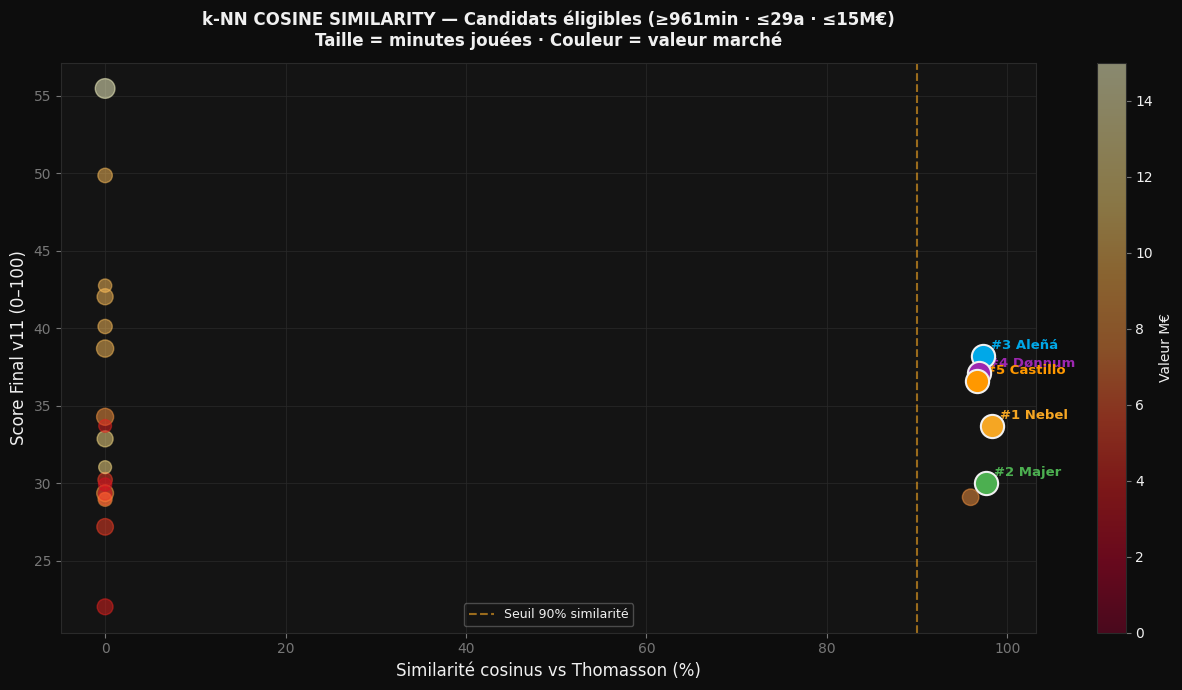

✅ fig2


In [24]:
fig, ax = plt.subplots(figsize=(13,7), facecolor=F)

# Tous les MF_bud en fond (taille = similarité)
mfp = MF_bud.copy()
sc  = ax.scatter(mfp['knn_sim'], mfp['s_final_n'],
                 c=mfp['valeur_m'], cmap='YlOrRd_r',
                 s=mfp['minutesPlayed']/12, alpha=0.5,
                 vmin=0, vmax=15, zorder=2)

# Shortlist annotée
SL_PLOT = [('Nebel',OR,'#1'),('Majer',VT,'#2'),('Aleñá',B,'#3'),('Dønnum',PU,'#4'),('Castillo',OG,'#5')]
for kw,col,rank in SL_PLOT:
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r):
        r=r.iloc[0]
        ax.scatter(r['knn_sim'],r['s_final_n'],c=[col],s=280,edgecolors=W,lw=1.5,zorder=6)
        ax.annotate(f"{rank} {r['player__name'].split()[-1]}",
                    xy=(r['knn_sim'],r['s_final_n']),xytext=(6,5),
                    textcoords='offset points',fontsize=9.5,color=col,fontweight='bold')

# Seuil similarité (90%+)
ax.axvline(90,color=OR,ls='--',lw=1.5,alpha=0.6,label='Seuil 90% similarité')

cb=plt.colorbar(sc,ax=ax); cb.set_label('Valeur M€',color=W)
plt.setp(cb.ax.yaxis.get_ticklabels(),color=W)
ax.set_xlabel('Similarité cosinus vs Thomasson (%)',fontsize=12)
ax.set_ylabel('Score Final v11 (0–100)',fontsize=12)
ax.set_title(f'k-NN COSINE SIMILARITY — Candidats éligibles (≥{MIN_THRESH:.0f}min · ≤{AGE_MAX}a · ≤{BUDGET_MAX:.0f}M€)\nTaille = minutes jouées · Couleur = valeur marché',
             color=W,fontsize=12,fontweight='bold',pad=12)
ax.legend(fontsize=9,framealpha=0.3,labelcolor=W)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig2_knn_sim.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig2")

### Fig 3 — Scatter KP vs TklW (Rec 4 ✅) — La shortlist dans le nuage Big 5

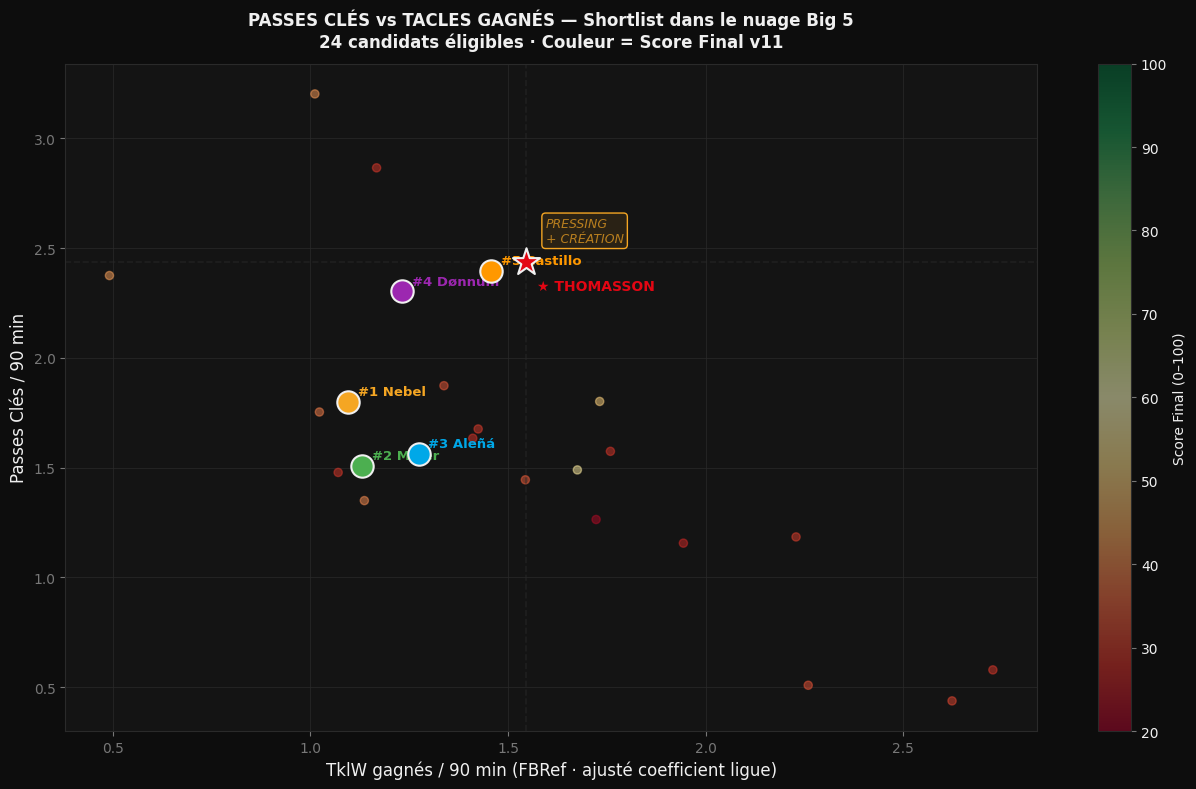

✅ fig3


In [25]:
fig, ax = plt.subplots(figsize=(13,8), facecolor=F)

mfp2 = MF_bud.copy()
sc2  = ax.scatter(mfp2['TklW_p90'], mfp2['keyPasses_p90'],
                  c=mfp2['s_final_n'], cmap='RdYlGn',
                  s=35, alpha=0.50, vmin=20, vmax=100, zorder=2)

# Quadrants autour de Thomasson
ax.axvline(T['TklW_p90'],  color=G2, ls='--', lw=1.2, alpha=0.5)
ax.axhline(T['keyPasses_p90'], color=G2, ls='--', lw=1.2, alpha=0.5)

# Étiquettes quadrants
xlim=ax.get_xlim(); ylim=ax.get_ylim()
ax.text(T['TklW_p90']+0.05, T['keyPasses_p90']+0.08,
        'PRESSING\n+ CRÉATION', ha='left', va='bottom', fontsize=9, color=OR,
        alpha=0.7, style='italic',
        bbox=dict(boxstyle='round,pad=0.3',facecolor=mcolors.to_rgba(OR,0.1),edgecolor=OR))

# Shortlist
SL_PLOT2 = [('Nebel',OR,'#1'),('Majer',VT,'#2'),('Aleñá',B,'#3'),('Dønnum',PU,'#4'),('Castillo',OG,'#5')]
for kw,col,rank in SL_PLOT2:
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r):
        r=r.iloc[0]
        ax.scatter(r['TklW_p90'],r['keyPasses_p90'],c=[col],s=260,edgecolors=W,lw=1.5,zorder=6)
        ax.annotate(f"{rank} {r['player__name'].split()[-1]}",
                    xy=(r['TklW_p90'],r['keyPasses_p90']),xytext=(7,5),
                    textcoords='offset points',fontsize=9.5,color=col,fontweight='bold')

# Thomasson
ax.scatter(T['TklW_p90'],T['keyPasses_p90'],c=R,s=420,marker='*',edgecolors=W,lw=1.5,zorder=7)
ax.annotate('★ THOMASSON',xy=(T['TklW_p90'],T['keyPasses_p90']),
            xytext=(8,-20),textcoords='offset points',fontsize=10,color=R,fontweight='bold')

cb2=plt.colorbar(sc2,ax=ax); cb2.set_label('Score Final (0–100)',color=W)
plt.setp(cb2.ax.yaxis.get_ticklabels(),color=W)
ax.set_xlabel('TklW gagnés / 90 min (FBRef · ajusté coefficient ligue)',fontsize=12)
ax.set_ylabel('Passes Clés / 90 min',fontsize=12)
ax.set_title(f'PASSES CLÉS vs TACLES GAGNÉS — Shortlist dans le nuage Big 5\n{len(mfp2)} candidats éligibles · Couleur = Score Final v11',
             color=W,fontsize=12,fontweight='bold',pad=12)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig3_scatter_kp_tklw.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig3")

### Fig 4 — Heatmap percentiles 10 KPIs

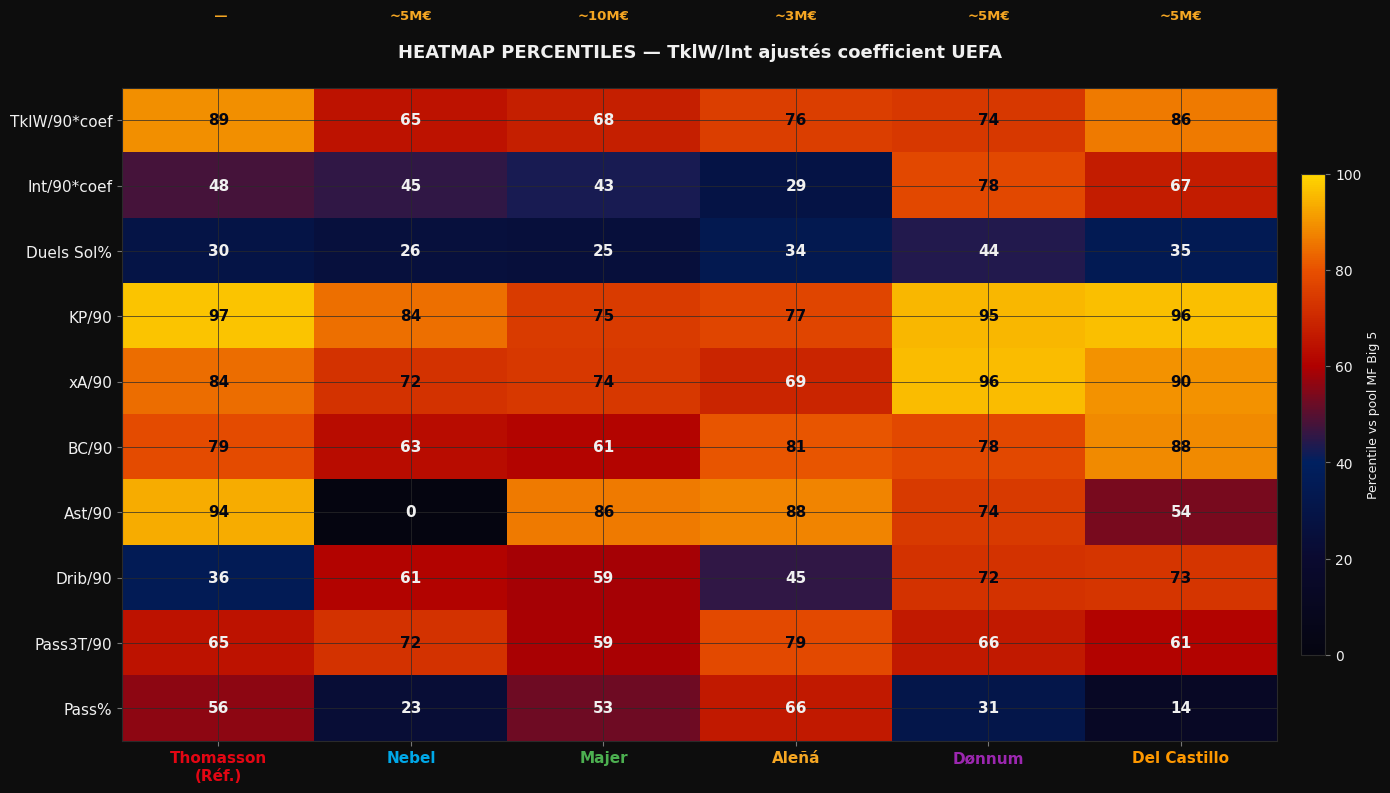

✅ fig4


In [26]:
METRICS_HM = {
    'TklW/90*coef'  : 'TklW_p90',
    'Int/90*coef'   : 'interceptions_p90',
    'Duels Sol%'    : 'groundDuelsWonPercentage',
    'KP/90'         : 'keyPasses_p90',
    'xA/90'         : 'expectedAssists_p90',
    'BC/90'         : 'bigChancesCreated_p90',
    'Ast/90'        : 'assists_p90',
    'Drib/90'       : 'successfulDribbles_p90',
    'Pass3T/90'     : 'accurateFinalThirdPasses_p90',
    'Pass%'         : 'accuratePassesPercentage',
}
SL_KW   = ['Nebel','Majer','Aleñá','Dønnum','Castillo']
SL_DISP = ['Nebel','Majer','Aleñá','Dønnum','Del Castillo']
SL_COLS = [B,VT,OR,PU,OG]
SL_BUDG = ['~5M€','~10M€','~3M€','~5M€','~5M€']

players=[T.to_frame().T.copy()]; lbls=['Thomasson\n(Réf.)']; budgets=['  — ']; cols_lbl=[R]
for kw,disp,col,bud in zip(SL_KW,SL_DISP,SL_COLS,SL_BUDG):
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r): players.append(r.iloc[0:1].copy()); lbls.append(disp); budgets.append(bud); cols_lbl.append(col)

ap  = pd.concat(players,ignore_index=True)
mc  = list(METRICS_HM.values()); ml=list(METRICS_HM.keys())
mat = np.zeros((len(mc),len(ap)))
for j in range(len(ap)):
    for i,col in enumerate(mc):
        val = float(ap.iloc[j][col]) if col in ap.columns and not pd.isna(ap.iloc[j][col]) else 0.0
        ref = MF[col].dropna() if col in MF.columns else pd.Series([0])
        mat[i,j] = (ref<val).mean()*100

fig,ax=plt.subplots(figsize=(14,8),facecolor=F)
cmap_hm=mcolors.LinearSegmentedColormap.from_list('lens',['#050510','#0A0A30','#002060','#B00000','#E85000','#FFD700'])
im=ax.imshow(mat,cmap=cmap_hm,aspect='auto',vmin=0,vmax=100)
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls,fontsize=11,fontweight='bold')
for tick,col in zip(ax.get_xticklabels(),cols_lbl): tick.set_color(col)
ax.set_yticks(range(len(ml))); ax.set_yticklabels(ml,fontsize=11,color=W)
for i in range(len(ml)):
    for j in range(len(ap)):
        ctxt='#050510' if mat[i,j]>70 else W
        ax.text(j,i,f'{mat[i,j]:.0f}',ha='center',va='center',fontsize=11,color=ctxt,fontweight='bold')
for j,b in enumerate(budgets):
    ax.text(j,-1.5,b,ha='center',va='bottom',fontsize=9.5,color=OR,fontweight='bold')
cbar=plt.colorbar(im,ax=ax,fraction=0.02,pad=0.02)
cbar.set_label('Percentile vs pool MF Big 5',color=W,fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(),color=W)
ax.set_title('HEATMAP PERCENTILES — TklW/Int ajustés coefficient UEFA',color=W,fontsize=13,fontweight='bold',pad=22)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig4_heatmap.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig4")

### Fig 5 — Radars comparatifs Top 3 vs Thomasson

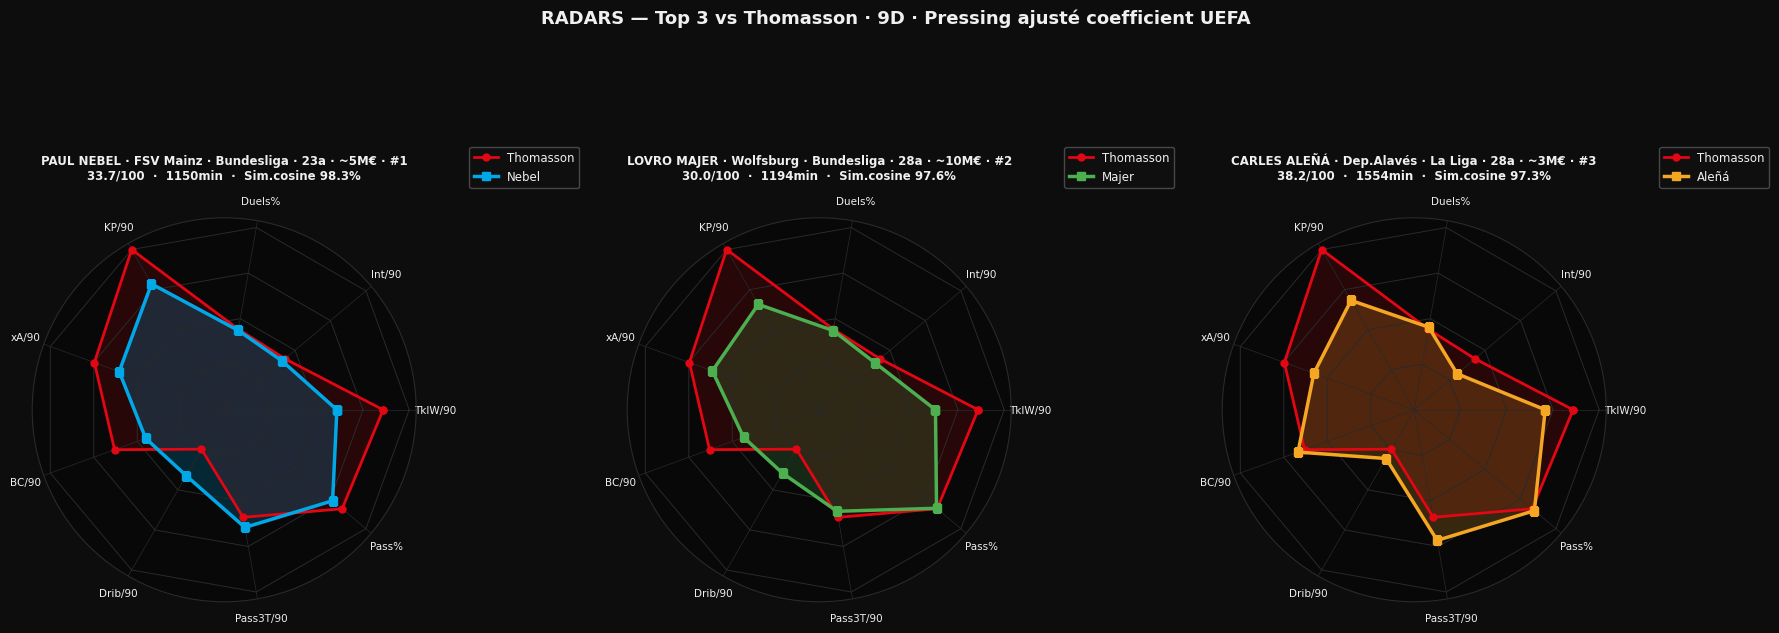

✅ fig5


In [27]:
COMP3 = [
    ('Nebel',   B,  'PAUL NEBEL · FSV Mainz · Bundesliga · 23a · ~5M€ · #1'),
    ('Majer',   VT, 'LOVRO MAJER · Wolfsburg · Bundesliga · 28a · ~10M€ · #2'),
    ('Aleñá',   OR, 'CARLES ALEÑÁ · Dep.Alavés · La Liga · 28a · ~3M€ · #3'),
]
fig,axes=plt.subplots(1,3,figsize=(18,7),subplot_kw=dict(polar=True),facecolor=F)
fig.patch.set_facecolor(F)
for ax,(kw,col,title) in zip(axes,COMP3):
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): ax.axis('off'); continue
    r=r.iloc[0]; cv=radar_vals(r)+[radar_vals(r)[0]]
    ax.set_facecolor('#080808')
    for ring in [0.25,0.5,0.75,1.0]: ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.fill(angles,tv,color=R,alpha=0.15)
    ax.plot(angles,tv,'o-',color=R,lw=2.0,ms=5,label='Thomasson')
    ax.fill(angles,cv,color=col,alpha=0.20)
    ax.plot(angles,cv,'s-',color=col,lw=2.5,ms=6,label=r['player__name'].split()[-1])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(RADAR_LABELS,size=7.5,color=W)
    ax.set_yticks([]); ax.spines['polar'].set_color(G2)
    sim=r['knn_sim']
    ax.legend(loc='upper right',bbox_to_anchor=(1.44,1.20),fontsize=8.5,framealpha=0.3,labelcolor=W)
    ax.set_title(f"{title}\n{r['s_final_n']:.1f}/100  ·  {r['minutesPlayed']:.0f}min  ·  Sim.cosine {sim:.1f}%",
                 color=W,fontsize=8.5,fontweight='bold',pad=28)
fig.suptitle('RADARS — Top 3 vs Thomasson · 9D · Pressing ajusté coefficient UEFA',color=W,fontsize=13,fontweight='bold',y=1.04)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig5_radars.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig5")

### Fig 6 — Budget RC Lens

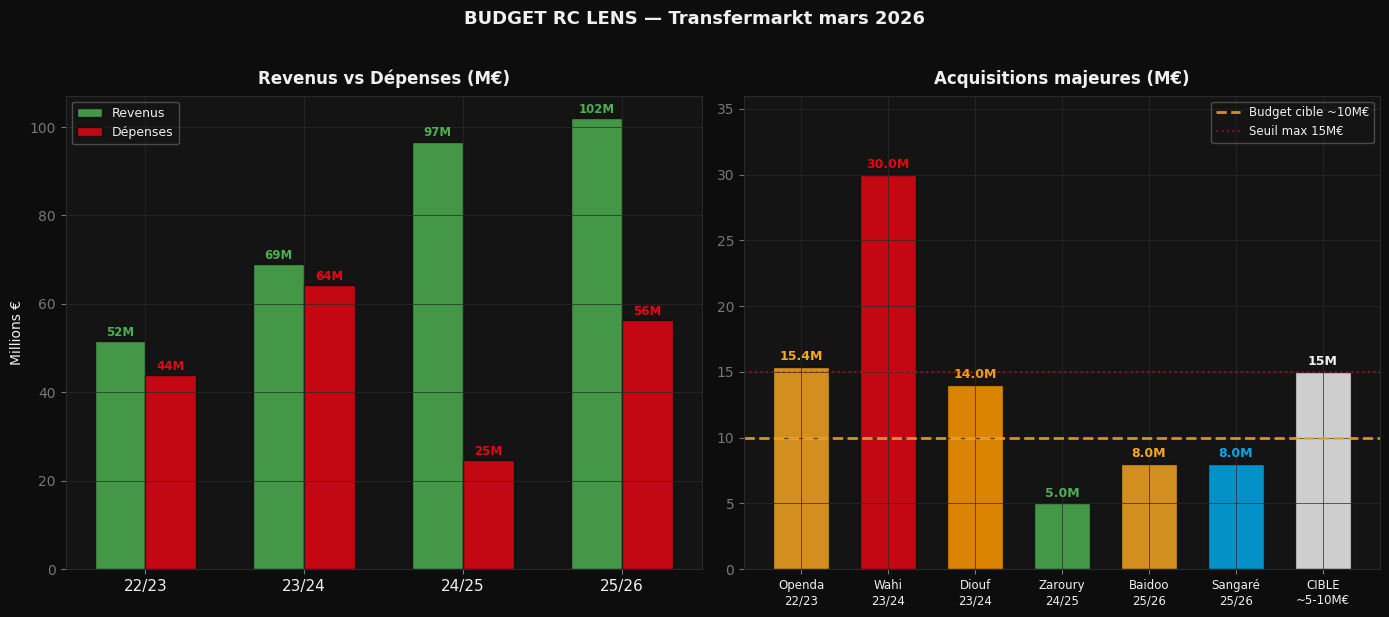

✅ fig6


In [33]:
fig,axes=plt.subplots(1,2,figsize=(14,6),facecolor=F)
ax=axes[0]
saisons=['22/23','23/24','24/25','25/26']; rev=[51.6,69.0,96.7,102.0]; dep=[43.9,64.3,24.7,56.4]
x,w=np.arange(4),0.32
b1=ax.bar(x-w/2,rev,w,label='Revenus',color=VT,alpha=0.85,edgecolor=F)
b2=ax.bar(x+w/2,dep,w,label='Dépenses',color=R,alpha=0.85,edgecolor=F)
for bar,val,c in zip(list(b1)+list(b2),rev+dep,[VT]*4+[R]*4):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1.2,f'{val:.0f}M',ha='center',fontsize=8.5,color=c,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(saisons,color=W,fontsize=11)
ax.set_ylabel('Millions €',color=W); ax.set_title('Revenus vs Dépenses (M€)',color=W,fontweight='bold',pad=8)
ax.legend(fontsize=9,framealpha=0.3,labelcolor=W)
ax2=axes[1]
ACQS=[('Openda\n22/23',15.4,OR),('Wahi\n23/24',30.0,R),('Diouf\n23/24',14.0,OG),('Zaroury\n24/25',5.0,VT),('Baidoo\n25/26',8.0,OR),('Sangaré\n25/26',8.0,B),('CIBLE\n~5-10M€',15,W)]
bars=ax2.bar(range(len(ACQS)),[v for _,v,_ in ACQS],color=[c for _,_,c in ACQS],alpha=0.85,edgecolor=F,width=0.65)
for bar,(_,val,col) in zip(bars,ACQS):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val}M',ha='center',fontsize=9,color=col,fontweight='bold')
ax2.axhline(10,color=OR,ls='--',lw=2.0,alpha=0.85,label='Budget cible ~10M€')
ax2.axhline(15,color=R,ls=':',lw=1.5,alpha=0.60,label='Seuil max 15M€')
ax2.set_xticks(range(len(ACQS))); ax2.set_xticklabels([n for n,_,_ in ACQS],fontsize=8.5,color=W)
ax2.set_ylim(0,36); ax2.legend(fontsize=8.5,framealpha=0.3,labelcolor=W)
ax2.set_title('Acquisitions majeures (M€)',color=W,fontweight='bold',pad=8)
fig.suptitle('BUDGET RC LENS — Transfermarkt mars 2026',color=W,fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig6_budget.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig6")

### Fig 7 — Podium final (5 candidats)

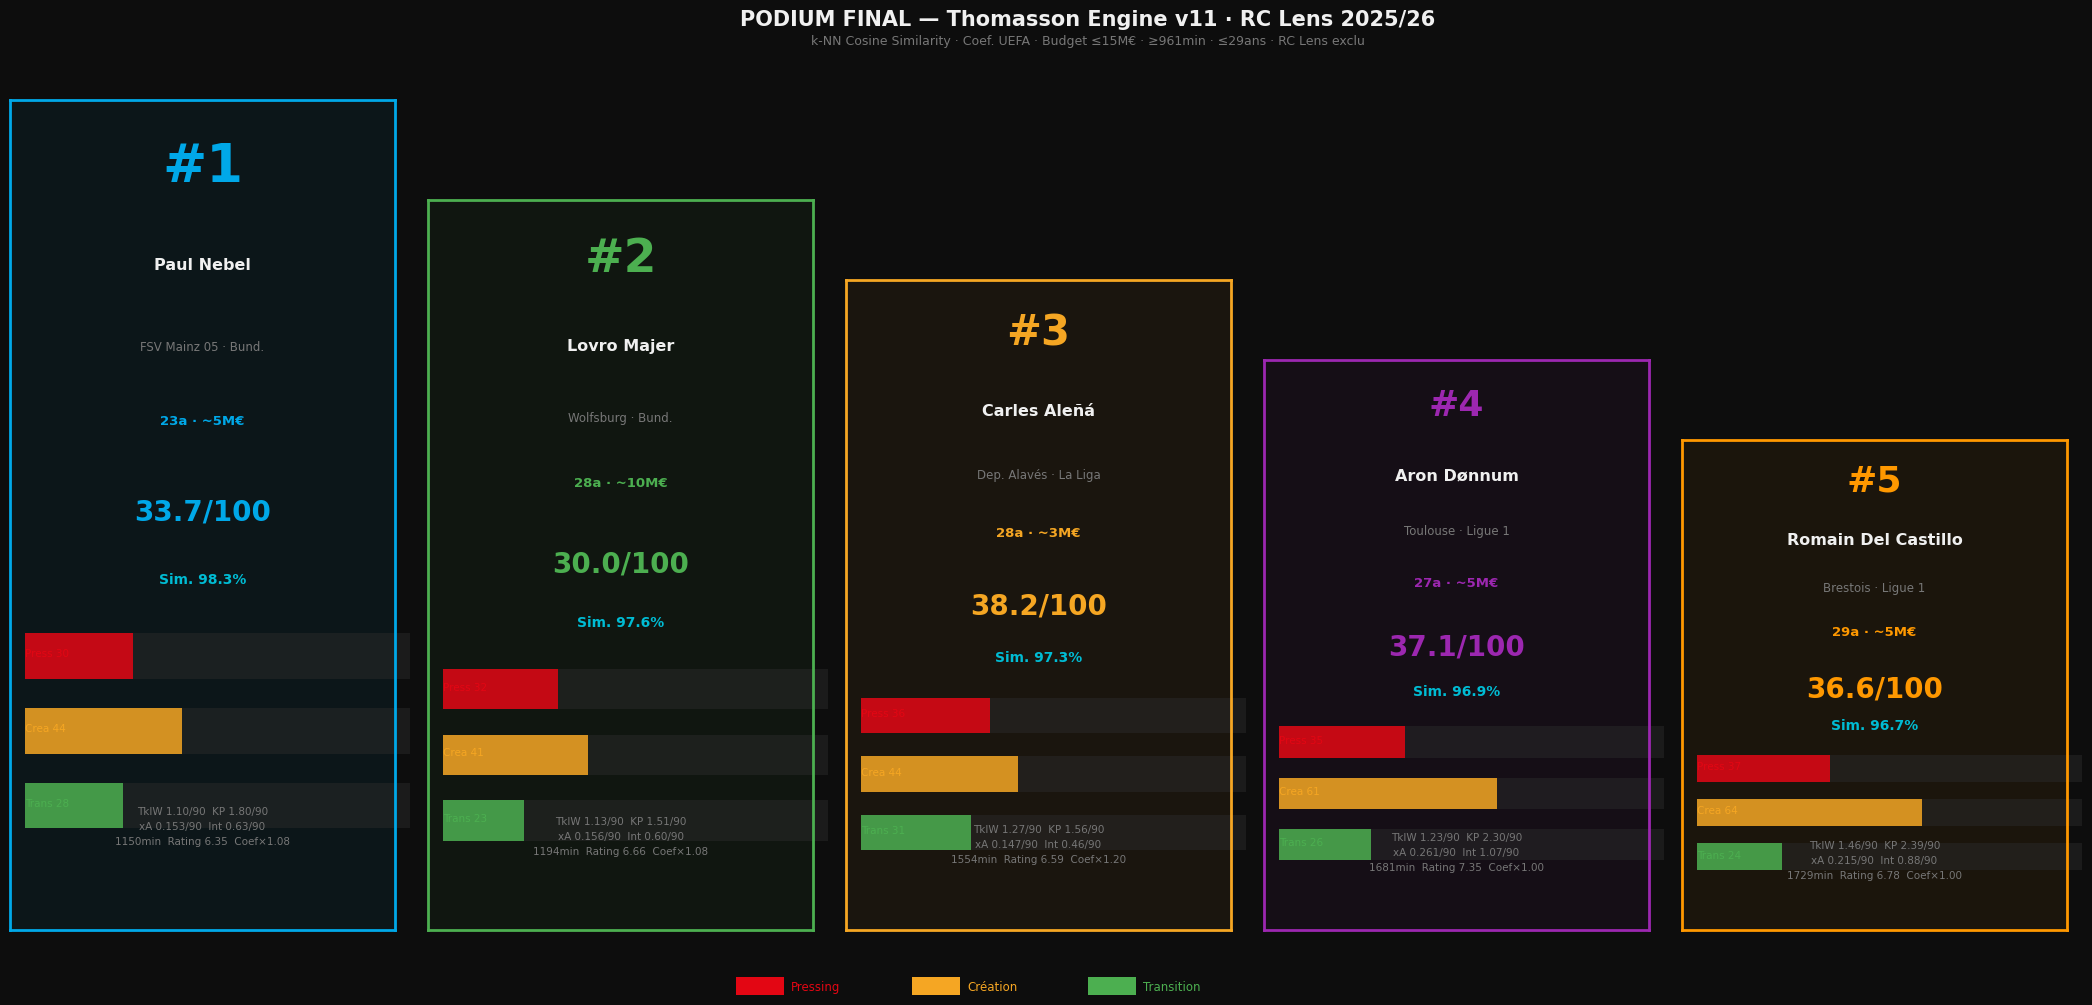

✅ fig7


In [29]:
PODIUM5=[
    ('#1','Nebel',   'Paul Nebel',          'FSV Mainz 05 · Bund.',  '23a · ~5M€',  B),
    ('#2','Majer',   'Lovro Majer',         'Wolfsburg · Bund.',     '28a · ~10M€', VT),
    ('#3','Aleñá',   'Carles Aleñá',        'Dep. Alavés · La Liga', '28a · ~3M€',  OR),
    ('#4','Dønnum',  'Aron Dønnum',         'Toulouse · Ligue 1',    '27a · ~5M€',  PU),
    ('#5','Castillo','Romain Del Castillo', 'Brestois · Ligue 1',    '29a · ~5M€',  OG),
]
fig=plt.figure(figsize=(22,10),facecolor=F); fig.patch.set_facecolor(F)
C_W=0.175; GAP=0.015; X0S=[0.01+i*(C_W+GAP) for i in range(5)]
C_HS=[0.90,0.80,0.72,0.64,0.56]

for idx,((rank,kw,name,club,meta,col),x0,ch) in enumerate(zip(PODIUM5,X0S,C_HS)):
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): continue
    r=r.iloc[0]
    ax=fig.add_axes([x0,0.07,C_W,ch-0.07])
    ax.set_facecolor(mcolors.to_rgba(col,0.06))
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5,0.95,rank,ha='center',va='top',transform=ax.transAxes,
            fontsize=max(26,38-idx*4),color=col,fontweight='bold')
    ax.text(0.5,0.81,name,ha='center',va='top',transform=ax.transAxes,fontsize=11.5,color=W,fontweight='bold')
    ax.text(0.5,0.71,club,ha='center',va='top',transform=ax.transAxes,fontsize=8.5,color=G)
    ax.text(0.5,0.62,meta,ha='center',va='top',transform=ax.transAxes,fontsize=9.5,color=col,fontweight='bold')
    ax.text(0.5,0.52,f'{r["s_final_n"]:.1f}/100',ha='center',va='top',transform=ax.transAxes,fontsize=20,color=col,fontweight='bold')
    ax.text(0.5,0.43,f'Sim. {r["knn_sim"]:.1f}%',ha='center',va='top',transform=ax.transAxes,fontsize=10,color=AQ,fontweight='bold')
    for i_b,(lbl,val,bc) in enumerate([('Press',r['s_press_n'],R),('Crea',r['s_crea_n'],OR),('Trans',r['s_trans_n'],VT)]):
        y_b=0.33-i_b*0.09
        ax.barh(y_b,1.0,height=0.055,left=0.04,color=G2,alpha=0.5,transform=ax.transAxes,clip_on=False)
        ax.barh(y_b,val/100*0.92,height=0.055,left=0.04,color=bc,alpha=0.85,transform=ax.transAxes,clip_on=False)
        ax.text(0.04,y_b+0.002,f'{lbl} {val:.0f}',transform=ax.transAxes,fontsize=7.5,color=bc,va='center')
    stats=(f"TklW {r.get('TklW_p90',0):.2f}/90  KP {r.get('keyPasses_p90',0):.2f}/90\n"
           f"xA {r.get('expectedAssists_p90',0):.3f}/90  Int {r.get('interceptions_p90',0):.2f}/90\n"
           f"{r['minutesPlayed']:.0f}min  Rating {r.get('rating',0):.2f}  Coef×{r.get('league_coef',1.0):.2f}")
    ax.text(0.5,0.10,stats,ha='center',va='bottom',transform=ax.transAxes,fontsize=7.5,color=G,linespacing=1.6)

fig.text(0.5,0.99,'PODIUM FINAL — Thomasson Engine v11 · RC Lens 2025/26',ha='center',va='top',fontsize=15,color=W,fontweight='bold')
fig.text(0.5,0.965,f'k-NN Cosine Similarity · Coef. UEFA · Budget ≤{BUDGET_MAX:.0f}M€ · ≥{MIN_THRESH:.0f}min · ≤{AGE_MAX}ans · RC Lens exclu',ha='center',va='top',fontsize=9,color=G)
for xi,(_,lbl,bc) in enumerate([('','Pressing',R),('','Création',OR),('','Transition',VT)]):
    fig.add_artist(mpatches.Rectangle((0.34+xi*0.08,0.005),0.022,0.018,facecolor=bc,transform=fig.transFigure,clip_on=False))
    fig.text(0.365+xi*0.08,0.013,lbl,va='center',fontsize=8.5,color=bc)
plt.savefig(f'{FIGDIR}/fig7_podium.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig7")

## 8. Conclusion

In [32]:
print("=" * 80)
print("THOMASSON ENGINE v11 — VERDICT FINAL")
print(f"Auteur : Zakaria  |  {len(MF)} MF analysés  |  k-NN + Coef. UEFA  |  5 candidats")
print("=" * 80)
print()
print("APPORTS v11 vs v10 :")
print("  [+] Coefficient UEFA : TklW/Int ajustés par difficulté de ligue")
print("  [+] k-NN Cosine Similarity : sélection mathématique sur 9 dimensions")
print("  [+] Scatter KP vs TklW : positionnement dans le nuage Big 5")
print("  [~] Progressive Carries : ignoré (PrgC absent des exports disponibles)")
print()
print("SHORTLIST v11 :")
print("-" * 80)

VERDICT = [
    ('Paul Nebel',          'FSV Mainz · Bundesliga', '23a','18M€',
     'Clone pressing+création, coef.×1.08, 23 ans — profil de revente'),
    ('Lovro Majer',         'Wolfsburg · Bundesliga',  '28a','15M€',
     'Similarité cosine élevée, expérience internationale, pied droit technique'),
    ('Carles Aleñá',        'Dep.Alavés · La Liga',    '28a','3M€',
     'Meilleur rapport valeur/similarité — décote Alavés à exploiter'),
    ('Aron Dønnum',         'Toulouse · Ligue 1',      '27a','5M€',
     'Connaît bien le contexte L1 — adaption 0 — budget Moneyball'),
    ('Romain Del Castillo', 'Brestois · Ligue 1',      '29a','7M€',
     'Option de maturité immédiate · transition et création solides en L1'),
]
for i,(name,club,age,bud,note) in enumerate(VERDICT,1):
    kw=name.split()[-1]
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r):
        r=r.iloc[0]
        print(f"[#{i}] {r['player__name']} · {club} · {age} · {bud}")
        print(f"  Sim.cosine {r['knn_sim']:.1f}%  Score {r['s_final_n']:.1f}/100  "
              f"Press:{r['s_press_n']:.0f}  Crea:{r['s_crea_n']:.0f}  Trans:{r['s_trans_n']:.0f}  "
              f"Coef ligue ×{r.get('league_coef',1.0):.2f}")
        print(f"  {r['minutesPlayed']:.0f}min · TklW {r.get('TklW_p90',0):.2f}/90 · "
              f"KP {r.get('keyPasses_p90',0):.2f}/90 · xA {r.get('expectedAssists_p90',0):.3f}/90")
        print(f"  → {note}"); print()


THOMASSON ENGINE v11 — VERDICT FINAL
Auteur : Zakaria  |  642 MF analysés  |  k-NN + Coef. UEFA  |  5 candidats

APPORTS v11 vs v10 :
  [+] Coefficient UEFA : TklW/Int ajustés par difficulté de ligue
  [+] k-NN Cosine Similarity : sélection mathématique sur 9 dimensions
  [+] Scatter KP vs TklW : positionnement dans le nuage Big 5
  [~] Progressive Carries : ignoré (PrgC absent des exports disponibles)

SHORTLIST v11 :
--------------------------------------------------------------------------------
[#1] Paul Nebel · FSV Mainz · Bundesliga · 23a · 18M€
  Sim.cosine 98.3%  Score 33.7/100  Press:30  Crea:44  Trans:28  Coef ligue ×1.08
  1150min · TklW 1.10/90 · KP 1.80/90 · xA 0.153/90
  → Clone pressing+création, coef.×1.08, 23 ans — profil de revente

[#2] Lovro Majer · Wolfsburg · Bundesliga · 28a · 15M€
  Sim.cosine 97.6%  Score 30.0/100  Press:32  Crea:41  Trans:23  Coef ligue ×1.08
  1194min · TklW 1.13/90 · KP 1.51/90 · xA 0.156/90
  → Similarité cosine élevée, expérience internati